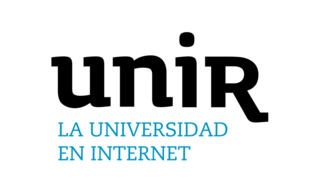

_Aprendizaje Automático_

_Máster Universitario en Inteligencia Artificial_

# Actividad: Clasificación con máquinas de vectores de soporte y random forest

## Objetivos

Mediante esta actividad se pretende que ponga en práctica la creación de modelos basados en máquinas de vector de soporte y random forest. El objetivo es comprender de forma práctica con un problema determinado las diferencias que existen a la hora de entrenar los diferentes modelos.

- Comprender el tratamiento de datos que hay que realizar para los modelos de clasificación.
- Entender y aplicar el algoritmo de Random Forest a un problema de clasificación.
- Entender y aplicar el algoritmo de Support Vector Machine a un problema de clasificación.
- Evaluar y analizar los resultados de los clasificadores.
- Investigar la aplicación de los modelos de clasificación a problemas reales.


## Descripción de la actividad

Debes completar los espacios indicados en el notebook con el código solicitado y la respuesta, en función de lo que se solicite. Ten encuenta que las celdas vacías indican cuántas líneas debe ocupar la respuesta, por lo general no más de una línea.

El conjunto de datos con el que vamos a trabajar se encuentra en el siguiente enlace: https://archive.ics.uci.edu/dataset/31/covertype

Este dataset ha sido generado para predecir el tipo de cubierta forestal únicamente a partir de variables cartográficas (sin datos de sensores remotos). El tipo de cubierta forestal real para una observación determinada (celda de 30 x 30 metros) se determinó a partir de los datos del Sistema de información de recursos (RIS) de la Región 2 del Servicio Forestal de EE. UU. (USFS). Las variables independientes se derivaron de datos obtenidos originalmente del Servicio Geológico de EE. UU. (USGS) y de datos del USFS. Los datos están en forma original (no escalados) y contienen columnas binarias (0 o 1) de datos para variables cualitativas independientes (áreas silvestres y tipos de suelo).
Para ampliar información sobre el dataset y su origen, recomendamos leer la descripción completa del dataset en el enlace del repositorio. l.

El objetivo de la clasificación será detectar el tipo de suelo.

### Tareas que se deben realizar

- Análisis descriptivo de los datos:
   - Debe completarse el código solicitado y responder a las preguntas. Todo ello en el notebook dado como base.
- Clasificación:
  - Debe completarse el código solicitado y responder a las preguntas. Todo ello en el notebook dado como base.
- Investigación:
  - Buscar un artículo científico (https://scholar.google.es/) con un caso de uso de clasificación empleando una de las dos técnicas (o ambas) vistas en la actividad. Los artículos deben estar en revistas científicas, y deben ser posteriores a 2015. No debe utilizar técnicas de Deep Learning.
  - Para el artículo indicar:
    - Objetivo: cuál es el objetivo de la investigación, es decir a qué problema real está aplicando la clasificación.
    - Cómo utilizan las técnicas de clasificación, si realizan alguna adaptación de los algoritmos indicarse.
    - Principales resultados de la aplicación y de la investigación.


### Análisis descriptivo de los datos

In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

In [2]:
# se carga el dataset
# df = pd.read_csv('covertype/covtype.csv')

from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
covertype = fetch_ucirepo(id=31) 
  
# data (as pandas dataframes) 
df = covertype.data.features 
df_y = covertype.data.targets 
  
# metadata 
# print(covertype.metadata) 
  
# variable information 
# print(covertype.variables) 


In [3]:
df = pd.concat([df, df_y], axis=1)

¿Cuántas instancias de datos tiene el dataset?

In [43]:
## PON AQUÍ TU CÓDIGO

df.shape

(581012, 55)

## PON AQUÍ TU RESPUESTA

Tiene 581012 instancias totales

¿Cuántas variables continuas hay en el dataset?

In [19]:
# Identificar columnas binarias
binary_cols = [col for col in df.columns if df[col].nunique() == 2]
print(f"Variables binarias: {binary_cols}")

len(binary_cols)

Variables binarias: ['Wilderness_Area1', 'Soil_Type1', 'Soil_Type2', 'Soil_Type3', 'Soil_Type4', 'Soil_Type5', 'Soil_Type6', 'Soil_Type7', 'Soil_Type8', 'Soil_Type9', 'Soil_Type10', 'Soil_Type11', 'Soil_Type12', 'Soil_Type13', 'Soil_Type14', 'Soil_Type15', 'Soil_Type16', 'Soil_Type17', 'Soil_Type18', 'Soil_Type19', 'Soil_Type20', 'Soil_Type21', 'Soil_Type22', 'Soil_Type23', 'Soil_Type24', 'Soil_Type25', 'Soil_Type26', 'Soil_Type27', 'Soil_Type28', 'Soil_Type29', 'Soil_Type30', 'Soil_Type31', 'Soil_Type32', 'Soil_Type33', 'Soil_Type34', 'Soil_Type35', 'Soil_Type36', 'Soil_Type37', 'Soil_Type38', 'Soil_Type39', 'Soil_Type40', 'Wilderness_Area2', 'Wilderness_Area3', 'Wilderness_Area4']


44

In [12]:
## PON AQUÍ TU CÓDIGO

continuous_cols = df.select_dtypes(include=['float64', 'int64']).columns
len(continuous_cols)

54

El dataset tiene un total de 54 variables numéricas. Sin embargo, muchas de ellas son binarias, como por ejemplo el tipo de suelo, que sólo coge valor 1 cuando la instancia corresponde a ese tipo de suelo. Por ello, el total de columnas binarias son 44, mientras que el total de numéricas son 54. Como estas binarias están representadas como numéricas en el dataset cuando en realidad no lo son, se puede concluir con que:

Hay 54 - 44 = 10 variables continuas en el dataset.

¿Cuántas variables categóricas hay en el dataset? Indica las categorías.

En el apartado anterior se ha establecido que existen un total de 54 columnas, de las cuales 44 son binarias y 10 continuas. Tomando en cuenta que las variables binarias se pueden considerar categóricas, las categorías de estas 44 features serían 1 y 0. Estas variables binarias, pese a ser 44 en total, se podrían resumir en 2: area y tipo de suelo. Como existen cuatro áreas y 40 tipos de suelo diferente, estas únicamente reflejaran con un 1 el tipo de suelo y área de cada instancia. Esto también está reflejado en la explicacion original del dataset, por lo que se puede contrastar. De esta manera, aunque hay 44 binarias, se podría afirmar que realmente hay únicamente dos variables categóricas.

Por otro lado, no se debe olvidar la variable target, contenida en otro df. A pesar de que esté definida como int, al tener únicamente 7 valores diferentes se puede determinar como variable categórica. Las categorías, como se puede observar en el siguiente fragmento de código, son representadas por los valores del 1 al 7. No se sabe a qué valores textuales se refiere, ya que están ya codificadas probablemente, mediante la técnica One-Hot Encoder.

In [28]:
unique_values_list = df_y['Cover_Type'].unique()
print(f"Valores únicos en 'Cover_Type': {unique_values_list}")

Valores únicos en 'Cover_Type': [5 2 1 7 3 6 4]


¿Cómo es la distribución de etiquetas de clase en el dataset? Con estos datos, ¿podríamos decir que el dataset está balanceado?

In [36]:
## PON AQUÍ TU CÓDIGO

distribution = df_y['Cover_Type'].value_counts()

print("Distribucion de las etiquetas de clase:")
print(distribution)

Distribucion de las etiquetas de clase:
Cover_Type
2    283301
1    211840
3     35754
7     20510
6     17367
5      9493
4      2747
Name: count, dtype: int64


El dataset está claramente desbalanceado. Las clases 1 y 2 tienen muchas más instancias que las demás. Por otro lado, las clases 4 y 5, sobre todo la 5, tiene una cantidad de instancias mucho menor.

¿Existen valores nulos o perdidos en el dataset?

In [ ]:
## PON AQUÍ TU CÓDIGO

missing_values = df.isnull().sum()

print("Número de valores nulos por columna:")
print(missing_values)

Número de valores nulos por columna:
Elevation                             0
Aspect                                0
Slope                                 0
Horizontal_Distance_To_Hydrology      0
Vertical_Distance_To_Hydrology        0
Horizontal_Distance_To_Roadways       0
Hillshade_9am                         0
Hillshade_Noon                        0
Hillshade_3pm                         0
Horizontal_Distance_To_Fire_Points    0
Wilderness_Area1                      0
Soil_Type1                            0
Soil_Type2                            0
Soil_Type3                            0
Soil_Type4                            0
Soil_Type5                            0
Soil_Type6                            0
Soil_Type7                            0
Soil_Type8                            0
Soil_Type9                            0
Soil_Type10                           0
Soil_Type11                           0
Soil_Type12                           0
Soil_Type13                           0
Soi

No existen valores nulos

¿Existe alguna variable altamente correlacionada con la variable de clase?

_Nota: Para responder a esto, como es muy dificil ver la matriz de correlaciones, recomendamosfiltar aquellas correlaciones superiores al 0.80 con la variable de clase.

In [ ]:
## PON AQUÍ TU CÓDIGO

correlation_matrix = df.corr()

high_corr = correlation_matrix['Cover_Type'][abs(correlation_matrix['Cover_Type']) > 0.80]

print("Variables altamente correlacionadas con 'Cover_Type':")
print(high_corr)

Variables altamente correlacionadas con 'Cover_Type':
Cover_Type    1.0
Name: Cover_Type, dtype: float64


Filtrando aquellas variables que tengan una correlación superior a 0.8, se obtiene que no existe ninguna. Esto es especialmente importante para tareas de clasificación, sobre todo si se van a utilizar SVM, por lo que es una apreciación interesante

¿Qué tres variables del dataset consideras que pueden influenciar más en la clasificación de los datos?¿Qué pruebas harías para comprobar tus hipótesis? Hazlas.

Las tres variables que considero que pueden influenciar más a la clasificación son:
1. Elevation: la elevación de un terreno es probable que influya en la tipología de cobertura forestal, ya que los árboles crecen según la altitud a la que encuentren. Para observar esto se calcularán las medias de elevación por clase, y también se hará un gráfico que muestre los valores de elevacion por clase, de manera que se pueda determinar si existe diferencia.

2. Soil_Type: el tipo de suelo es muy importante para saber le tipo de plantasa que crecen en lugar. Esta variable, repartida en 40 binarias, puede tener una alta correlación con la variable target. Para analizar si hay correlación, se estudiará la chi-cuadrado de cada variable binaria buscando conocer si cada tipo de suelo tiene alguna relación con la variable target. Los resultados iguales o cercanos a 0 indicarán que existe un relación directa. SI el resultado es muy alto (cercano a uno), indicará que ese tipo concreto de suelo no.


3. Wilderness_area: el área silvestre por último, debería poder tener relación con los árboles que crecen. Se hará lo mismo que para el tipo de suelo.

              Elevation
Cover_Type             
1           3128.644888
2           2920.936061
3           2394.509845
4           2223.939934
5           2787.417571
6           2419.181897
7           3361.928669


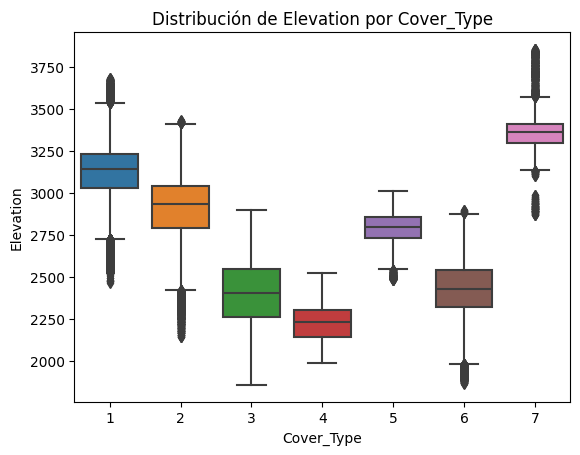

In [51]:
# 1. Elevation

elevation_corr = df[['Elevation', 'Cover_Type']].groupby('Cover_Type').mean()
print(elevation_corr)

sns.boxplot(x='Cover_Type', y='Elevation', data=df)
plt.title('Distribución de Elevation por Cover_Type')
plt.show()

Se puede observar, sobremanera en el gráfico, que existe diferencia en los valores de altitud según la clase. Por ejemplo, el valor mínimo de elevación de la clase 1 apenas consigue alcanzar la mayoría de valores de la clase 4. Se puede identificar una relación directa.

In [ ]:
# Soil Type

from scipy.stats import chi2_contingency

soil_type_columns = [f'Soil_Type{i}' for i in range(1, 41)]
for col in soil_type_columns:
    contingency_table = pd.crosstab(df[col], df['Cover_Type'])
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    print(f"Chi-squared Test for {col} vs Cover_Type: p-value = {p}")

Chi-squared Test for Soil_Type1 vs Cover_Type: p-value = 0.0
Chi-squared Test for Soil_Type2 vs Cover_Type: p-value = 0.0
Chi-squared Test for Soil_Type3 vs Cover_Type: p-value = 0.0
Chi-squared Test for Soil_Type4 vs Cover_Type: p-value = 0.0
Chi-squared Test for Soil_Type5 vs Cover_Type: p-value = 0.0
Chi-squared Test for Soil_Type6 vs Cover_Type: p-value = 0.0
Chi-squared Test for Soil_Type7 vs Cover_Type: p-value = 1.7129654908603296e-21
Chi-squared Test for Soil_Type8 vs Cover_Type: p-value = 2.4898563581535384e-11
Chi-squared Test for Soil_Type9 vs Cover_Type: p-value = 3.892084170771216e-138
Chi-squared Test for Soil_Type10 vs Cover_Type: p-value = 0.0
Chi-squared Test for Soil_Type11 vs Cover_Type: p-value = 0.0
Chi-squared Test for Soil_Type12 vs Cover_Type: p-value = 0.0
Chi-squared Test for Soil_Type13 vs Cover_Type: p-value = 0.0
Chi-squared Test for Soil_Type14 vs Cover_Type: p-value = 0.0
Chi-squared Test for Soil_Type15 vs Cover_Type: p-value = 8.890831242782292e-19
Chi-

Como se observa, todos los resultados son o 0 o valores muy cercanos a 0 (elevados a altas potencias negativas). Esto indica que existe una dependencia estadística entre las categorías de suelo y las clases de forestal. Esto significa que la presencia de un tipo de suelo concreto tiene alta tendencia a estar asociada a un tipo de cobertura forestal determinado.

In [55]:
# 3. Wilderness Area

wilderness_area_columns = [f'Wilderness_Area{i}' for i in range(1, 5)]
for col in wilderness_area_columns:
    contingency_table = pd.crosstab(df[col], df['Cover_Type'])
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    print(f"Chi-squared Test for {col} vs Cover_Type: p-value = {p}")

Chi-squared Test for Wilderness_Area1 vs Cover_Type: p-value = 0.0
Chi-squared Test for Wilderness_Area2 vs Cover_Type: p-value = 0.0
Chi-squared Test for Wilderness_Area3 vs Cover_Type: p-value = 0.0
Chi-squared Test for Wilderness_Area4 vs Cover_Type: p-value = 0.0


Los p-valores, al igual que el tipo de suelo, son iguales a 0. Esto indica también una dependencia, por lo que se confirma también la última hipótesis propuesta.

In [56]:
# Separamos los datos en los conjuntos de entrenamiento y test.
from sklearn.model_selection import train_test_split

X, y = df.drop('Cover_Type',axis=1),df['Cover_Type']

X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=0.2, random_state=1)

### Clasificación

**Random Forest**

En esta parte de la actividad hay que utilizar la librería https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html para resolver el problema de clasificación.

El algortimo de RF necesitar ajustar una serie de hiperparámetros para realizar las clasificaciones. La implementación de sklearn nos da mucha flexibilidad para nuestros modelos. En general, para los problemas más comunes de clasificación, nos tenemos que preocupar de los siguientes hiperparámetros:
- n_estimators
- criterion
- max_depth
- min_samples_split
- min_samples_leaf
- max_features

Indica qué son cada uno de estos hiperparámetros

- n_estimators: se refiere al número total de árboles que tiene el bosque, es decir, el total de árboles de decisión que tratarán de modelar los datos.

- criterion: es el criterio que utiliza cada árbol para medir la calidad de división de cada uno de los nodos. Por defecto se encuentra el ínidice Gini, aunque se puede cambiar por otros como la entropía.

- max_depth: como su nombre indica, es la profundidad máxima que puede alcanzar cada árbol, de tal manera que se pueda controlar la complejidad del modelo y tratar de evitar el overfitting.

- min_samples_split: se refiere al mnúmero mínimo de muestras que debe tener un nodo para poder se dividido. El valor por defecto es dos, pero se puede aumentar este valor también para evitar el overfitting.

- min_samples_leaf: se refiere al número mínimo de muestras que debe tener una hoja del árbol.

- max_features: este hiperparámetro permite limitar el número de característicaas con las que cada árbol del bosque va a trabajar. De esta manera se puede evitar correlaciones entre los árboles y obtener resultados más interesantes.

Además de los hiperparámetros que acabas de descubrir, la implementación de sklearn tiene el hiperparámetro _class_weight_

¿Qué indica ese parámetro? ¿Para qué puede ser útil?

Este parámetro se suele utilizar para controlar problemas de clasificación en los que las clases están desbalanceadas, es decir, que hay clases mucho más representadas que otras, como ocurre en este caso.
Este hiperparámetro permite asignar un peso distinto a cada una de las clases para penalizar más los errores que el modelo realice clasificando las clases con menor número de instancias. Así, se mejora el rendimiento del modelo al tratar de prestar más atención a estas clases.

Como primer paso para crear un clasificador de Random Forest hay que decidir si hay que hacer algún preprocesamiento adicional sobre los datos.
¿Hace falta normalizar los datos?

In [ ]:
## PON AQUÍ TU RESPUESTA Y/O CÓDIGO


Para entrenar un modelo debasado en el algoritmo Random Forest no es necesario normalizar los datos, aunque tampoco estaría mal como tal. La decisión es que para esta implementación en concreto no se normalizarán. RF, al realizar divisiones de cada nodo basadas en comparaciones de los valores de las features, no le afecta la escala de las variables, al igual que sí ocurria con modelos como la regresión logística. Es por ello que las variables no necesitan estar en la misma escala.

Entrena un conjunto de modelos de Random Forest que utilicen todas las variables del dataset, con 5, 10, 20, 50 y 100 árboles. El criterio para realizar las particiones debe ser Gini-index, la profundidad máxima de los árboles debe ser 10, el número mínimo de ejemplos para realizar una partición debe ser 10, el número mínimo de ejemplos para considerarlo una hoja debe ser 2, y el número máximo de características deben ser todas.

_Nota: el entrenamiento puede tardar entre 3 y 15 minutos en función de las características del equipo._

In [57]:
# numero de árboles: 5, 10, 20, 50 y 100
from sklearn.ensemble import RandomForestClassifier

n_arboles = [5, 10, 20, 50, 100]
particion = 'gini'
max_depth = 10
min_samples_split = 10
min_samples_leaf = 2
max_feature = None

randomForest = [RandomForestClassifier(n_estimators = i, criterion= particion,
                                       max_depth = max_depth, min_samples_split = min_samples_split,
                                      min_samples_leaf = min_samples_leaf, max_features =None) for i in n_arboles]


In [ ]:
# PON AQUÍ TU CÓDIGO PARA EL ENTRENAMIENTO

In [58]:
randomForest_models = []

for model in randomForest:
    model.fit(X_train, y_train)
    randomForest_models.append(model)

Visualiza la matriz de confusión del modelo entrenado con 20 árboles.

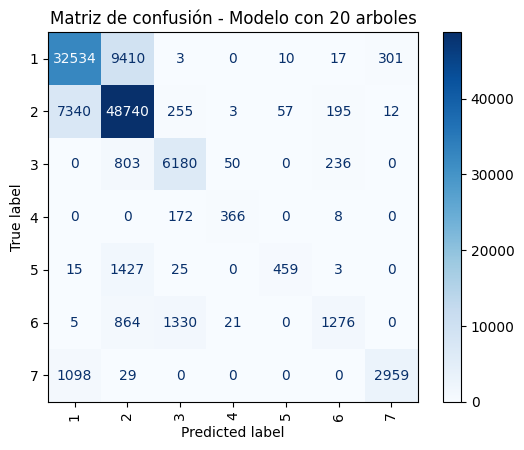

In [ ]:
## PON AQUÍ TU CÓDIGO

from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

model_20_trees = randomForest[2]  
y_pred = model_20_trees.predict(X_test)
conf_matrix = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=model_20_trees.classes_)
disp.plot(cmap=plt.cm.Blues, xticks_rotation='vertical')
plt.title("Matriz de confusión - Modelo con 20 arboles")
plt.show()

In [63]:
correctly_classified = conf_matrix.diagonal().sum()

print(f"Ejemplos correctamente clasificados: {correctly_classified}")

Ejemplos correctamente clasificados: 92514


In [64]:
incorrectly_classified = conf_matrix.sum() - conf_matrix.diagonal().sum()

print(f"Ejemplos clasificados incorrectamente: {incorrectly_classified}")

Ejemplos clasificados incorrectamente: 23689


In [65]:
total = conf_matrix.sum() 

print(f"Total ejemplos: {total}")

Total ejemplos: 116203


¿Cuántos ejemplos ha clasificado correctamente?

De los 116203 instancias en test, un total de 92514 se han clasificado correctamente, quedando 23689 mal clasificadas.

Explica cómo funciona la clasificación para cada una de las 7 clases. ¿Hay alguna clase que clasifica mejor que otras?

In [67]:
correct_classification_percentage = conf_matrix.diagonal() / conf_matrix.sum(axis=1) * 100

for i, percentage in enumerate(correct_classification_percentage):
    print(f"Clase {i+1}: {percentage:.2f}% correctamente clasificados")

Clase 1: 76.96% correctamente clasificados
Clase 2: 86.11% correctamente clasificados
Clase 3: 85.02% correctamente clasificados
Clase 4: 67.03% correctamente clasificados
Clase 5: 23.79% correctamente clasificados
Clase 6: 36.50% correctamente clasificados
Clase 7: 72.42% correctamente clasificados


En el código anterior se han mostrado los porcentajes de acierto de cada una de las clases. Como se observa, clases como la 2, 3 e incluso la 1 obtienen resultados que comienzan a ser interesantes, clasificando correctamente más del 75% de las instancias. Sin embargo, existen clases como la 5 que apenas clasifican bien un 25% de las instancias, lo cual es muy bajo. 

¿Cuál de todos los modelos que has entrenado obtiene mejores resultados de precisión para el conjunto de datos de test?

_Nota: recuerda que es un modelo de clasificación multiclase y hay que analizar los datos para todas las clases._

In [75]:
## PON AQUÍ TU CÓDIGO Y RESPUESTA

from sklearn.metrics import accuracy_score, precision_score

accuracies = {}

for i, model in enumerate(randomForest):
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    
    total_accuracy = accuracy_score(y_test, y_pred)
    accuracies[f"Modelo con {n_arboles[i]} árboles"] = total_accuracy
    
    print(f"Modelo con {n_arboles[i]} árboles:")
    print(f"Precisión total: {total_accuracy:.4f}")
    
    for class_label in range(1, 8): 
        class_precision = precision_score(y_test, y_pred, labels=[class_label], average='micro')
        print(f"Precisión clase {class_label}: {class_precision:.4f}")

Modelo con 5 árboles:
Precisión total: 0.7932
Precisión clase 1: 0.7942
Precisión clase 2: 0.7924
Precisión clase 3: 0.7676
Precisión clase 4: 0.8136
Precisión clase 5: 0.8571
Precisión clase 6: 0.6922
Precisión clase 7: 0.8993
Modelo con 10 árboles:
Precisión total: 0.7941
Precisión clase 1: 0.7889
Precisión clase 2: 0.7944
Precisión clase 3: 0.7751
Precisión clase 4: 0.8194
Precisión clase 5: 0.8731
Precisión clase 6: 0.7658
Precisión clase 7: 0.8958
Modelo con 20 árboles:
Precisión total: 0.7949
Precisión clase 1: 0.7865
Precisión clase 2: 0.7981
Precisión clase 3: 0.7678
Precisión clase 4: 0.8371
Precisión clase 5: 0.8360
Precisión clase 6: 0.7906
Precisión clase 7: 0.8976
Modelo con 50 árboles:
Precisión total: 0.7945
Precisión clase 1: 0.7887
Precisión clase 2: 0.7963
Precisión clase 3: 0.7702
Precisión clase 4: 0.8474
Precisión clase 5: 0.8561
Precisión clase 6: 0.7475
Precisión clase 7: 0.8994
Modelo con 100 árboles:
Precisión total: 0.7949
Precisión clase 1: 0.7874
Precisión c

En cuanto a precisión total, el modelo con 20 y el modelo con 100 árboles obtienen resultados iguales y ligeramente superiror a los demás. Como se observa, el modelo con 5 árboles no es capaz de lograr una buena precisión para la clase 6. EL modelo de 10 árboles, pese a tener un poco menos de precisión total, tiene resultados muy interesantes. La precisión total de todos es similar, así que para el siguiente análisis se tomarán en cuenta las precisiones por clase.

Selecciona el modelo que consideras que obtiene mejores resultados para los resultados de test. Explica por qué consideras que ese modelo es el que mejor resultados obtiene.

En cuanto van creciendo el número de árboles a partir de 20, la precisión de la clase 6 va cayendo bastante, mientras que las otras apenas sufren variaciones, por lo que lo modelos de 50 y 100 se descartan como candidatos a ser el mejor. La precisión de la clase 6 del primer modelo con 5 árboles es bastante inferior, por lo que se podría descartar. Quedan como candidatos el modelo de 10 y el de 20 árboles. El de 20 tiene una precisión total ligeramente superior. Sin embargo, el de 10 clasifica mejor las clases 1, 3 y 5. Sobre todo para la clase 5 tiene unos resultados muy buenos y mucho mejores que todos los demás modelos (más de 0.87). Por ello, pese a que tanto el de 20 como el de 10 árboles podrían ser válidos candidatos, se escogerá el de 10 porque, ante un empate como el presente, se utilizará como criterio para el desempate el escoger aquel con menor costo computacional. Siempre tendrá menor costo el modelo con menos árboles, por lo que el escogido será el modelo de 10 árboles.

Visualiza la matriz de confusión de los datos de test de este modelo.
- ¿Cuántos ejemplos ha clasificado bien el modelo?
- ¿Cuántos ejemplos ha clasificado de manera errónea?

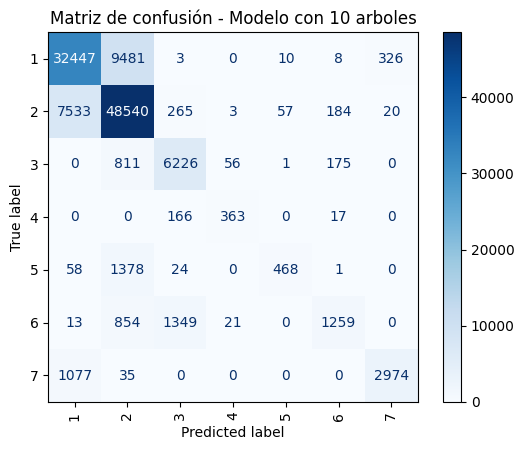

In [76]:
model_10_trees = randomForest[1]  
y_pred = model_10_trees.predict(X_test)
conf_matrix = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=model_10_trees.classes_)
disp.plot(cmap=plt.cm.Blues, xticks_rotation='vertical')
plt.title("Matriz de confusión - Modelo con 10 arboles")
plt.show()

In [77]:
correctly_classified = conf_matrix.diagonal().sum()

print(f"Ejemplos correctamente clasificados: {correctly_classified}")

Ejemplos correctamente clasificados: 92277


In [78]:
incorrectly_classified = conf_matrix.sum() - conf_matrix.diagonal().sum()

print(f"Ejemplos clasificados incorrectamente: {incorrectly_classified}")

Ejemplos clasificados incorrectamente: 23926


Visualiza los valores de precision, recall, f1 para cada una de las clases. 
- ¿Clasifica de igual manera todas las clases o hay alguna para la que el modelo tiene una mayor capacidad predictiva?

In [79]:
from sklearn.metrics import classification_report

modelo_rf_10 = randomForest[1] 
predicciones_10 = modelo_rf_10.predict(X_test)

reporte = classification_report(y_test, predicciones_10, output_dict=True)

df_reporte = pd.DataFrame(reporte).transpose()

print("\nMétricas por clase:\n")
print(df_reporte.loc[[str(i) for i in sorted(y_test.unique())], ["precision", "recall", "f1-score"]])


Métricas por clase:

   precision    recall  f1-score
1   0.788927  0.767522  0.778078
2   0.794448  0.857567  0.824802
3   0.775053  0.856514  0.813750
4   0.819413  0.664835  0.734075
5   0.873134  0.242613  0.379716
6   0.765815  0.360126  0.489883
7   0.895783  0.727851  0.803133


In [ ]:
### PON AQUÍ TU CÓDIGO E INDICA TU RESPUESTA

El modelo no clasifica igual para todas las clases. Las clases 1, 2, 3 y 7 tienen un buen equilibrio entre las métricas, indicando que el modelo aparte de tener precisión, también clasifica correctamente las instancias negativas (no pertenecientes a la clase). Esto es importante tenerlo en cuenta porque los modelos no sólo deben preocuparse por la precisión, que tiene en cuenta únicamente si ha clasificado bien los positivos (pertenecientes a la clase), sino también los negativos. La clase 4, por su parte, aporta resultados más bajos que los de las clases anteriores, si bien tampoco son tan malos, ya que el recall se sitúa por encima del 0.65. No es un buen resultado, pero tampoco es catastrófico. El problema aparece con las clases 5 y 6, que tienen un recall y f1 muy bajo. La clase 5 tiene una alta precisión mientras que el recall y ek f1 son muy bajos, lo que indica que el modelo ha tenido un bajo rendimiento en esta clase, sólo siendo capaz de clasificar bien las positivas. La clase 6, aún teniendo resultados ligeramente superiores, ninguna supera el 0.5, por lo que tampoco son buenos.

**Support Vector Machine**

In [4]:
# Importamos las librerías para utilizar las máquinas de vector de soportes.
# Utilizaremos la librería svm:

from sklearn import svm

#Cargamos también las librerías para hacer la matriz de confusión y la cross validation:

from sklearn import metrics
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import KFold

Para la implementación del modelo de clasificación de SVM usaremos la clase Support Vector Classifier de sklearn, https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html#sklearn.svm.SVC

El algoritmo de SVM necesita ajustar una serie de hiperparámetros para realizar las clasificaciones. La implementación de sklearn nos da mucha flexibilidad para nuestros modelos. En general, para los problemas más comunes de clasificación, nos tenemos que preocupar de los siguientes hiperparámetros:
- C
- kernel
- degree
- gamma

Indica qué son cada uno de estos hiperparámetros

- C: Es el parametro que controla el balance entre maximizar el margen de separación entre regiones y minimizar los errores de clasificación.

- kernel: determina el tipo de función que el modelo utiliza para transformar los datos a un espacio de mayor dimensión con el objetivo de obt3ener una separación lineal entre los datos.

- degree: este parámetro sólo es útil cuando se escoge un kernel polinómico, ya que representa el grado del polinomio que se usa para transformar la dimensionalidad de los datos. Cuanto mayor grado, más compleja es la transformación.

- gamma: se utiliza cuando se elige el kernel rbf, poly y sigmoid. Controla el peso de cada punto de entrenamiento en la transformación del espacio. Esto significa que un valor alto hace que los puntos cercanos tengan gran poder sobre la elección de la frontera de decisión, lo que puede conllevar a sobreajuste sobre los datos de entrenamiento.

Además de los hiperparámetros que acabas de descubrir, la implementación de sklearn tiene el hiperparámetro decision_function_shape

¿Qué indica ese parámetro? ¿Para qué puede ser útil?

Este prámetro define la forma en que se calcula la función de decisión en problemas de clasigicación multiclase, como el que se tiene en el proyecto presente. Esto es cómo determina el modelo la clase asignada a un puno de los datos cuando hay más de dos clases. Hay varios métodos, como ovr u ovo.
Este parámetro es util, como se ha comentado, en problemas multiclase, ya que permite escoger la estrategia de clasificación. Ovr es más eficiente ya que sólo entrena tantos clasificadores como clases haya. Ovo podría ser más preciso cuando se trate de un problema con una gran cardinalidad de clases o estas están separadas, ya que se entrenan más clasificadores.

Tenemos un dataset de más de medio millón de instancias, y para el objetivo de la actividad no hacen falta tantas. Por eso, antes de aplicar SVM vamos a reducir el número de instancias. SVM requiere una gran carga computacional y con ese volumen de instancias el tiempo requerido sería demasiado elevado.

In [ ]:
df = df.head(10000)

Nota: recuerda revisar que esta manera de seleccionar un subconjunto de instancias no altera la clase objetivo. Deberías tener un porcentaje similar de instancias de cada clase. Si no fuera así, deberás cambiar la manera de seleccionar el subconjunto.

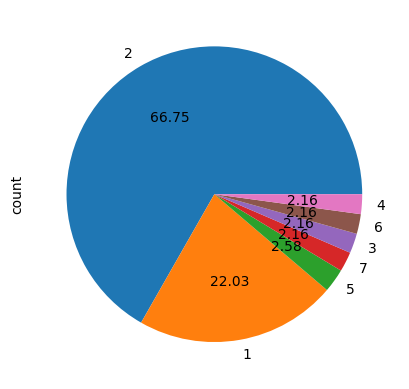

In [7]:
df['Cover_Type'].value_counts().plot(kind='pie',autopct='%.2f',)
plt.show()

Teniendo en cuenta lo visto en el EDA, las proporciones han cambiado, sobre todo en las clases 1 y 2, que antes eran diferentes. Para ello, se va a realizar un undersampling de tal forma que se pueda mantener las proporciones.

In [5]:
class_counts = df['Cover_Type'].value_counts()

proporciones = class_counts / class_counts.sum()

total_samples = 20000

samples_per_class = (proporciones * total_samples).astype(int)

undersampled_df = df.groupby('Cover_Type').apply(lambda x: x.sample(n=samples_per_class[x.name], random_state=1))

undersampled_df = undersampled_df.reset_index(drop=True)

print(undersampled_df['Cover_Type'].value_counts())

Cover_Type
2    9751
1    7292
3    1230
7     706
6     597
5     326
4      94
Name: count, dtype: int64


/tmp/ipykernel_73344/1060115239.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  undersampled_df = df.groupby('Cover_Type').apply(lambda x: x.sample(n=samples_per_class[x.name], random_state=1))


Posteriormente se probó a implementar el modelo con las 100000 instancias mencionadas. Sin embargo, tardaba más de una hora en ejecutar y se decidió trabajar con menor número de instancias. Tras probar varios subsets, se decidió trabajar con 20000 instancias, teniendo presente que puede no ser un número representativo, pero con el objetivo de poder realizar el ejercicio satisfactoriamente.

In [6]:
undersampled_df.shape

(19996, 55)

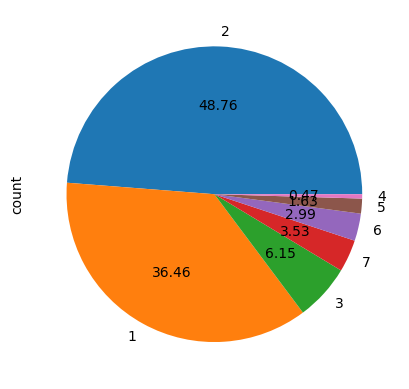

In [14]:
undersampled_df['Cover_Type'].value_counts().plot(kind='pie',autopct='%.2f',)
plt.show()

In [7]:
# Con el nuevo número de instancias, separamos los datos en los conjuntos de entrenamiento y test.
from sklearn.model_selection import train_test_split

X, y = undersampled_df.drop('Cover_Type',axis=1),undersampled_df['Cover_Type']

X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=0.2, random_state=1)


Como primer paso para crear un clasificador de SVM hay que decidir si hay que hacer algún preprocesamiento adicional sobre los datos. ¿Hace falta normalizar los datos?

Trabajando con SVM, si es buena práctica normalizar los datos, ya que este modelo es sensible a las escalas de las features. Pueden afectar al rendimiento ya que utiliza distancias entre los puntos del espacio de datos para encontrar los márgenes. Es importante escalar los datos de test bajo el mismo escalador que los datos de train para no afectar al rendimiento del modelo.

In [8]:
## PON AQUÍ TU CÓDIGO SI CONSIDERAS QUE HAY QUE NORMALIZAR LOS DATOS

from sklearn.preprocessing import StandardScaler
from pandas import DataFrame


scaler = StandardScaler()

## COMPLETAR

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

Entrena un conjunto de modelos de SVM que utilicen todas las variables del dataset, con C = 0.1 hasta 1000 con cinco valores diferentes; kernel radial, y gamma con valor scale.

In [9]:
from sklearn.svm import SVC

C = [0.1, 1, 10, 100, 1000]
kernel = 'rbf'
gamma = 'scale'

svc = [SVC(C=i, kernel=kernel, gamma=gamma) for i in C]
svc

[SVC(C=0.1), SVC(C=1), SVC(C=10), SVC(C=100), SVC(C=1000)]

In [10]:
for model in svc:
    model.fit(X_train, y_train)

In [ ]:
### PON AQUÍ TU CÓDIGO

In [11]:
from sklearn.metrics import classification_report, accuracy_score, f1_score

model_results = []

for model in svc:
    y_pred = model.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average='macro')
    f1_weighted = f1_score(y_test, y_pred, average='weighted')
    
    report = classification_report(y_test, y_pred, output_dict=True)
    
    model_results.append({
        'model': model,
        'accuracy': accuracy,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted,
        'classification_report': report
    })

for idx, result in enumerate(model_results):
    print(f"Modelo {idx + 1} (C={C[idx]}):")
    print(f"  Accuracy: {result['accuracy']:.4f}")
    print(f"  F1-Score Macro: {result['f1_macro']:.4f}")
    print(f"  F1-Score Weighted: {result['f1_weighted']:.4f}")
    print("  Classification Report (por clase):")
    print(result['classification_report'])
    print("\n" + "=" * 50 + "\n")

/home/sgomez/.cache/pypoetry/virtualenvs/unir-msc-ai-AuZ9bGHS-py3.11/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/sgomez/.cache/pypoetry/virtualenvs/unir-msc-ai-AuZ9bGHS-py3.11/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/sgomez/.cache/pypoetry/virtualenvs/unir-msc-ai-AuZ9bGHS-py3.11/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use 

Modelo 1 (C=0.1):
  Accuracy: 0.7087
  F1-Score Macro: 0.3828
  F1-Score Weighted: 0.6874
  Classification Report (por clase):
{'1': {'precision': 0.7254612546125462, 'recall': 0.6606182795698925, 'f1-score': 0.6915230390432642, 'support': 1488.0}, '2': {'precision': 0.7220461747397012, 'recall': 0.8234383066597831, 'f1-score': 0.769416304872166, 'support': 1937.0}, '3': {'precision': 0.553072625698324, 'recall': 0.8646288209606987, 'f1-score': 0.6746166950596252, 'support': 229.0}, '4': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 23.0}, '5': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 55.0}, '6': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 129.0}, '7': {'precision': 0.7564102564102564, 'recall': 0.4244604316546763, 'f1-score': 0.543778801843318, 'support': 139.0}, 'accuracy': 0.70875, 'macro avg': {'precision': 0.39385575878011825, 'recall': 0.3961636912635787, 'f1-score': 0.3827621201169105, 'support': 4000.0}, 'weighted avg': {'p

Después de hacer el entrenamiento, visualiza las matrices de confusión de los modelos entrenados.

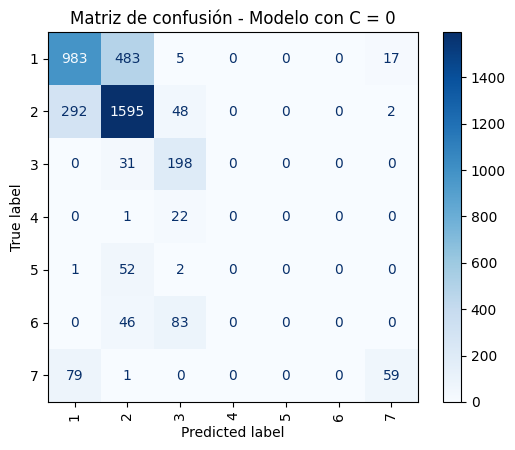

Modelo 1 (C=0.1):
Matriz de confusión (sin normalizar):
[[ 983  483    5    0    0    0   17]
 [ 292 1595   48    0    0    0    2]
 [   0   31  198    0    0    0    0]
 [   0    1   22    0    0    0    0]
 [   1   52    2    0    0    0    0]
 [   0   46   83    0    0    0    0]
 [  79    1    0    0    0    0   59]]
--------------------------------------------------


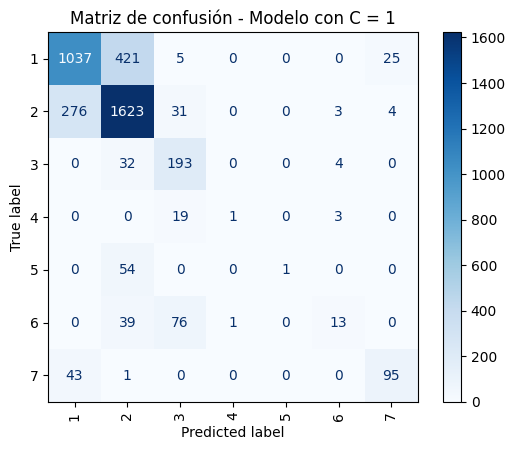

Modelo 2 (C=1):
Matriz de confusión (sin normalizar):
[[1037  421    5    0    0    0   25]
 [ 276 1623   31    0    0    3    4]
 [   0   32  193    0    0    4    0]
 [   0    0   19    1    0    3    0]
 [   0   54    0    0    1    0    0]
 [   0   39   76    1    0   13    0]
 [  43    1    0    0    0    0   95]]
--------------------------------------------------


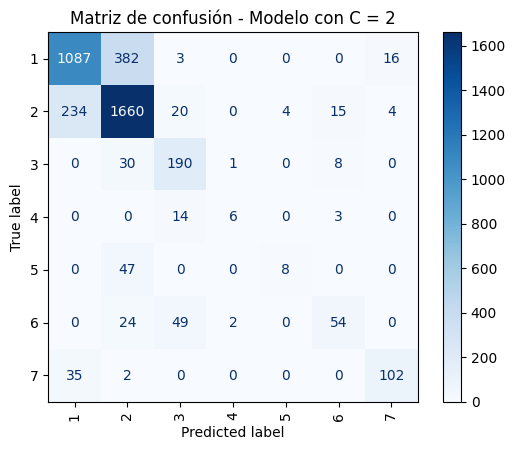

Modelo 3 (C=10):
Matriz de confusión (sin normalizar):
[[1087  382    3    0    0    0   16]
 [ 234 1660   20    0    4   15    4]
 [   0   30  190    1    0    8    0]
 [   0    0   14    6    0    3    0]
 [   0   47    0    0    8    0    0]
 [   0   24   49    2    0   54    0]
 [  35    2    0    0    0    0  102]]
--------------------------------------------------


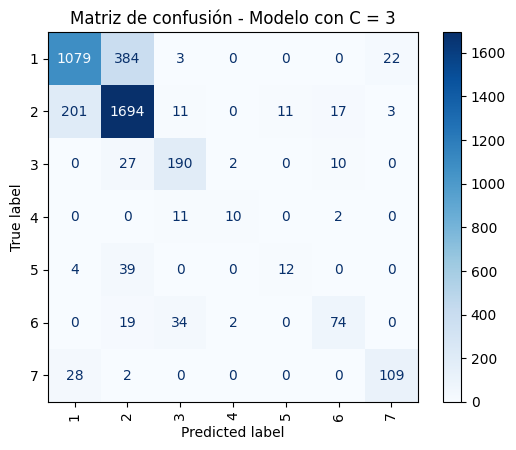

Modelo 4 (C=100):
Matriz de confusión (sin normalizar):
[[1079  384    3    0    0    0   22]
 [ 201 1694   11    0   11   17    3]
 [   0   27  190    2    0   10    0]
 [   0    0   11   10    0    2    0]
 [   4   39    0    0   12    0    0]
 [   0   19   34    2    0   74    0]
 [  28    2    0    0    0    0  109]]
--------------------------------------------------


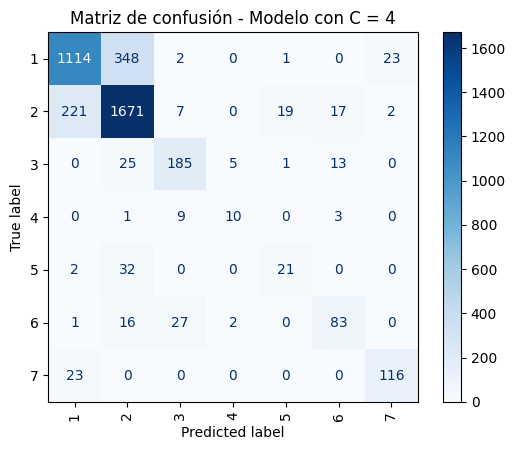

Modelo 5 (C=1000):
Matriz de confusión (sin normalizar):
[[1114  348    2    0    1    0   23]
 [ 221 1671    7    0   19   17    2]
 [   0   25  185    5    1   13    0]
 [   0    1    9   10    0    3    0]
 [   2   32    0    0   21    0    0]
 [   1   16   27    2    0   83    0]
 [  23    0    0    0    0    0  116]]
--------------------------------------------------


In [16]:
## PON AQUÍ TU CÓDIGO
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

for idx, model in enumerate(svc):
    y_pred = model.predict(X_test)  
    conf_matrix = confusion_matrix(y_test, y_pred)  

    disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=model.classes_)
    disp.plot(cmap=plt.cm.Blues, xticks_rotation='vertical')
    plt.title(f"Matriz de confusión - Modelo con C = {idx}")
    plt.show()

    print(f"Modelo {idx + 1} (C={C[idx]}):")
    print("Matriz de confusión (sin normalizar):")
    print(conf_matrix)
    print("-" * 50)

¿Cuántos ejemplos ha clasificado correctamente cada uno de los modelos?

In [17]:
for idx, model in enumerate(svc):
    y_pred = model.predict(X_test)  
    conf_matrix = confusion_matrix(y_test, y_pred)  

    correct_predictions = conf_matrix.trace() 

    print(f"Modelo {idx + 1} (C={C[idx]}):")
    print(f"Ejemplos clasificados correctamente: {correct_predictions}")
    print("-" * 50)


Modelo 1 (C=0.1):
Ejemplos clasificados correctamente: 2835
--------------------------------------------------
Modelo 2 (C=1):
Ejemplos clasificados correctamente: 2963
--------------------------------------------------
Modelo 3 (C=10):
Ejemplos clasificados correctamente: 3107
--------------------------------------------------
Modelo 4 (C=100):
Ejemplos clasificados correctamente: 3168
--------------------------------------------------
Modelo 5 (C=1000):
Ejemplos clasificados correctamente: 3200
--------------------------------------------------


¿Cuál de todos los modelos que has entrenado obtiene mejores resultados de precision para todas las clases? Si no hay ninguno que consideres que sea óptimo, explica cómo se comporta para cada clase el modelo que consideres que tiene mejores resultados.

Todos los modelos tienen bastante error. Sin embargo, el modelo 5, el que tiene el C=1000, parece que presenta menor error.

In [18]:
## PON AQUÍ TU CÓDIGO

conf_matrix = np.array([
    [1114, 348, 2, 0, 1, 0, 23],
    [221, 1671, 7, 0, 19, 17, 2],
    [0, 25, 185, 5, 1, 13, 0],
    [0, 1, 9, 10, 0, 3, 0],
    [2, 32, 0, 0, 21, 0, 0],
    [1, 16, 27, 2, 0, 83, 0],
    [23, 0, 0, 0, 0, 0, 116]
])

precisions = np.diag(conf_matrix) / np.sum(conf_matrix, axis=0)

for i, precision in enumerate(precisions):
    print(f"Precisión clase {i+1}: {precision:.3f}")

Precisión clase 1: 0.819
Precisión clase 2: 0.798
Precisión clase 3: 0.804
Precisión clase 4: 0.588
Precisión clase 5: 0.500
Precisión clase 6: 0.716
Precisión clase 7: 0.823


Como se observa en el fragmento anterior, obtiene una precisión relativamente buena para todas las clases excepto para la 4 y la 5 que recordando, también eran las que menor capacidad de predicción tenían cuando se implemento el random forest.

Selecciona el modelo que consideras que obtiene mejores resultados y realiza las predicciones con el conjunto de datos de test.

In [20]:
## PON AQUÍ TU CÓDIGO

best_model = svc[4]

y_pred_test = best_model.predict(X_test)

Visualiza la matriz de confusión de los datos de test.
- ¿Cuántos ejemplos ha clasificado bien el modelo?
- ¿Cuántos ejemplos ha clasificado de manera errónea?

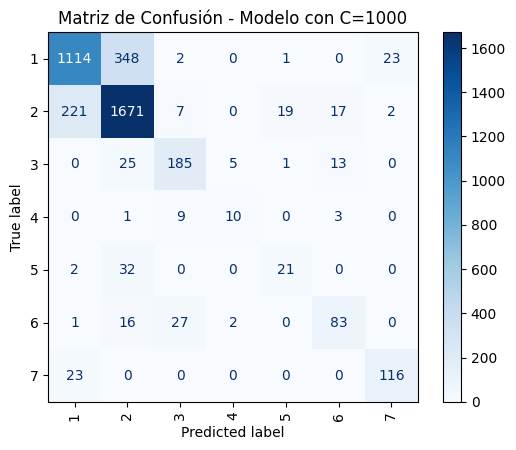

Ejemplos clasificados correctamente: 3200
Ejemplos clasificados incorrectamente: 800


In [21]:
### PON AQUÍ TU CÓDIGO E INDICA TU RESPUESTA

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

conf_matrix_test = confusion_matrix(y_test, y_pred_test)

disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_test, display_labels=best_model.classes_)
disp.plot(cmap=plt.cm.Blues, xticks_rotation='vertical')
plt.title("Matriz de Confusión - Modelo con C=1000")
plt.show()

correct_predictions = conf_matrix_test.trace() 
total_examples = conf_matrix_test.sum() 
incorrect_predictions = total_examples - correct_predictions 

print(f"Ejemplos clasificados correctamente: {correct_predictions}")
print(f"Ejemplos clasificados incorrectamente: {incorrect_predictions}")


Visualiza los valores de precision, recall, f1 para cada una de las clases. 
- ¿Clasifica de igual manera todas las clases o hay alguna para la que el modelo tiene una mayor capacidad predictiva?

In [23]:
### PON AQUÍ TU CÓDIGO E INDICA TU RESPUESTA

from sklearn.metrics import classification_report

y_pred_test = best_model.predict(X_test)

report = classification_report(y_test, y_pred_test)

print(report)


              precision    recall  f1-score   support

           1       0.82      0.75      0.78      1488
           2       0.80      0.86      0.83      1937
           3       0.80      0.81      0.81       229
           4       0.59      0.43      0.50        23
           5       0.50      0.38      0.43        55
           6       0.72      0.64      0.68       129
           7       0.82      0.83      0.83       139

    accuracy                           0.80      4000
   macro avg       0.72      0.67      0.69      4000
weighted avg       0.80      0.80      0.80      4000



No clasifica igual todas. Las clases 2, 3 y 7 tienen buen recall y precision. Sobretodo la clase 2 tienen un recall muy alto, lo que indica que se clasifica muy bien y tiene mayor poder predictivo en esta clase. La clase 1 aunque tiene un recall más bajo también tiene un f1 alto y por tanto se comporta bastante bien. La clase 6 se sitúa en un intermedio, no clasifica ni muy bien pero tampoc muy mal. Las clases 4 y 5 destacan por ser las peores, con bastante diferencia de las demás.

**Comparativa**

En base al EDA realizado, a las decisiones tomadas sobre los datos e hiperparámetros y a las características computacionales de tu equipo. ¿Qué modelo obtiene mejores resultados de clasificación?

En base a los resultados obtenidos:

1. Random Forest: 
               precision    recall  f1-score
           1   0.788927  0.767522  0.778078
           2   0.794448  0.857567  0.824802
           3   0.775053  0.856514  0.813750
           4   0.819413  0.664835  0.734075
           5   0.873134  0.242613  0.379716
           6   0.765815  0.360126  0.489883
           7   0.895783  0.727851  0.803133

2. SVM:
              precision    recall  f1-score   support

           1       0.82      0.75      0.78      1488
           2       0.80      0.86      0.83      1937
           3       0.80      0.81      0.81       229
           4       0.59      0.43      0.50        23
           5       0.50      0.38      0.43        55
           6       0.72      0.64      0.68       129
           7       0.82      0.83      0.83       139

Observando los resultados de los modelos elegidos, se pueden extraer varias conclusiones:
- En general, Random Forest tiene mejores resultados para las clases mayoritarias, pero su rendimiento es muy bajo para la clases poco presentes, como la 5 o la 6.
- SVM es mucho más equilibrado, ya que, aunque es un poco peor para algunas clases, no es tan malo en las clases minoritarias como random forest.
- SVM es muy superior a las capacidades de cómputo de mi ordenador, y sólo se ha podido probar con un subset de 20000 samples. Por ello, es de esperar que con un ordenador más potenete y utilizando más instnacias para el entrenamiento, mejore drásticamente.

En conclusión, dado que no se tiene información suficiente de negocio como para decidir que es mejor sacrificar las clases minoritas por una mejor clasificación de las mayoritarias, y SVM es mucho más equilibrado, se decide que SVM con C=1000 es la mejor implementación de modelo para el problema.

### Investigación

Buscar un artículo científico (https://scholar.google.es/) con un caso de uso de clasificación empleando una de las dos técnicas (o ambas) vistas en la actividad. Los artículos deben estar en revistas científicas, y deben ser posteriores a 2015. No debe utilizar técnicas de Deep Learning.

Comparison between random forest and support vector machine algorithms for LULC classification. Avci, C., Budak, M., Yagmur, N., & Bektas Balcik, F. International Journal of Environmental and Geoinformatics, 9(1), 1-10. (2022) https://doi.org/10.26833/ijeg.987605

título, autores, revista, año de publicación

Objetivo: cuál es el objetivo de la investigación, es decir a qué problema real está aplicando la clasificación.
Técnicas de clasificación empleadas y si realiza alguna adaptación.
Principales resultados de la aplicación y de la investigación.

- Objetivo: el experimento tiene como objetivo principal realizar una comparación entre los dos modelos que se han aplicado también para la presente prácticas: random forest y SVM, aplicados a clasificar el uso y la cobertura del suelo (o LULC) a partir de imágenes de satélites. De esta manera, la clasificación trata de clasificar sehún las áreas de humedades, un tipo de suelo, debido a su imporancia en el medio ambiente. Se defiende el experimento mencionando que lo humedales tienen un papel fundamental en el ciclo del agua, desarrollando un papel clave en la mitigacion del cambio climático. La investigación busca evaluar el desempeño de los dos alhoritmo para detectar este tipo de ecosistemas dentro de las imágenes de los satélties.

- Técnicas: como se ha mencionado, se emplearon dos técnicas. En rpimer lugar, se empleó un modelo basado en el algorimo random forest con el objetivo de clasificar correctamente los diferentes tipos de suelo, y para el que se utilizaron las características espectrales de las imágenes.
En segundo lugar, se utilizó un modelo basado en SVM, con el que se trató de encontrar el mejor hiperplano que separase todas las clases.

- Resultados: tras el análisis, se descubrió que random forest mostraba mejores resultados que SVM, sobremanera cuando se buscaba utilizar las 20 AOI por cada clase. Esto significa que rf es mejor que svm para la detección de diferentes tipos de suelo.